In [28]:
# Feedforward Neural Network implemented from scratch

import numpy as np
import pandas as pd
from pathlib import Path

dashline = "-" * 80

# 1. Load and prepare dataset
def load_insurance_data():
    """
    Load train and test CSVs from ./data, build numeric feature matrix X and
    target y = ClaimNb / Exposure.
    Returns features (as column-major: features x samples) and labels (1 x samples).
    """
    data_dir = Path("data")
    train_path = data_dir / "claims_train_clean.csv"
    test_path = data_dir / "claims_test_clean.csv"

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    # numeric features to use
    numeric_cols = ["Exposure", "VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]

    # build X, y
    eps = 1e-8
    X_train = train_df[numeric_cols].astype(float).values
    y_train = (train_df["ClaimNb"].astype(float).values /
               (train_df["Exposure"].astype(float).values + eps))

    X_test = test_df[numeric_cols].astype(float).values
    y_test = (test_df["ClaimNb"].astype(float).values /
              (test_df["Exposure"].astype(float).values + eps))

    # standardize features using training statistics
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0) + 1e-8

    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std

    # features as rows, samples as columns
    features_train = X_train_std.T          # shape: (num_features, num_train_samples)
    labels_train = y_train.reshape(1, -1)   # shape: (1, num_train_samples)

    features_test = X_test_std.T            # shape: (num_features, num_test_samples)
    labels_test = y_test.reshape(1, -1)     # shape: (1, num_test_samples)

    return features_train, labels_train, features_test, labels_test


# 2. Generate random starting weights & biases
def initial_parameters(layers):
    """
    layers: list like [input_dim, hidden1, hidden2, ..., output_dim]
    Returns dictionary of W1, b1, W2, b2, ...
    """
    parameters = {}
    num_layers = len(layers)

    for layer in range(1, num_layers):
        # W: (units_this_layer, units_prev_layer)
        parameters[f"W{layer}"] = np.random.randn(layers[layer], layers[layer - 1]) * 0.1
        # b: (units_this_layer, 1)
        parameters[f"b{layer}"] = np.zeros((layers[layer], 1))

    return parameters


# 3. Activation functions (ReLU, linear output)
def relu(weighted_sum):
    return np.maximum(weighted_sum, 0)


def relu_derivative(weighted_sum):
    return (weighted_sum > 0).astype(float)


# 4. Forward propagation
def forward_prop(features, parameters):
    """
    features: A0, shape (input_dim, m)
    parameters: dict of W1, b1, ..., WL, bL
    Returns:
        activations of last layer (AL), and cache {A0, Z1, A1, ..., ZL, AL}
    """
    cache = {}
    activations = features
    cache["A0"] = activations
    num_layers = len(parameters) // 2

    for layer in range(1, num_layers + 1):
        W = parameters[f"W{layer}"]
        b = parameters[f"b{layer}"]
        Z = W.dot(activations) + b   # (units_l, m)
        cache[f"Z{layer}"] = Z

        if layer < num_layers:
            # hidden layers: ReLU
            activations = relu(Z)
        else:
            # last layer: linear (regression output)
            activations = Z

        cache[f"A{layer}"] = activations

    return activations, cache  # AL, cache


# 5. Cost function (MSE)
def cost_function(predictions, labels):
    """
    predictions: AL, shape (1, m)
    labels: y, shape (1, m)
    MSE = 1/(2m) * sum (pred - y)^2
    """
    m = labels.shape[1]
    diff = predictions - labels
    cost = (1.0 / (2 * m)) * np.sum(diff ** 2)
    print("Cost:", cost)
    return cost


# 6. Backward propagation to compute gradients (for MSE + ReLU)
def backward_prop(labels, parameters, cache):
    """
    labels: shape (1, m)
    parameters: W1..WL, b1..bL
    cache: A0..AL, Z1..ZL
    Returns gradients dWl, dbl
    """
    gradients = {}
    num_layers = len(parameters) // 2
    m = labels.shape[1]

    # Last layer activations and inputs
    AL = cache[f"A{num_layers}"]  # (1, m) since output_dim = 1
    # derivative of MSE loss: L = 1/(2m) sum (AL - Y)^2 -> dL/dAL = (AL - Y) / m
    dAL = (AL - labels) / m       # (1, m)

    # Backprop through layers
    delta = dAL  # for last layer, activation is linear, so dZL = dAL

    for layer in reversed(range(1, num_layers + 1)):
        A_prev = cache[f"A{layer - 1}"]
        Z = cache[f"Z{layer}"]
        W = parameters[f"W{layer}"]

        # Gradients for this layer
        dW = delta.dot(A_prev.T)                     # (units_l, units_{l-1})
        db = np.sum(delta, axis=1, keepdims=True)    # (units_l, 1)

        gradients[f"dW{layer}"] = dW
        gradients[f"db{layer}"] = db

        if layer > 1:
            # Propagate error to previous layer
            dA_prev = W.T.dot(delta)                # (units_{l-1}, m)
            # Because hidden layers use ReLU:
            Z_prev = cache[f"Z{layer - 1}"]
            delta = dA_prev * relu_derivative(Z_prev)

    return gradients


# 7. Update parameters (gradient descent)
def gradient_descent(parameters, gradients, learning_rate):
    num_layers = len(parameters) // 2

    for layer in range(1, num_layers + 1):
        parameters[f"W{layer}"] -= learning_rate * gradients[f"dW{layer}"]
        parameters[f"b{layer}"] -= learning_rate * gradients[f"db{layer}"]

    return parameters


# 8. Train network
def train_model(features_train, labels_train, layers, max_iterations, learning_rate, tolerance):
    """
    features_train: X (input_dim, m)
    labels_train: y (1, m)
    layers: hidden+output layer sizes (e.g. [32, 1])
    """
    num_input_neurons = features_train.shape[0]
    full_layers = [num_input_neurons] + layers   # e.g. [6, 32, 1]

    parameters = initial_parameters(full_layers)
    previous_cost = float("inf")

    for iteration in range(max_iterations):
        # Forward
        AL, cache = forward_prop(features_train, parameters)
        # Cost
        current_cost = cost_function(AL, labels_train)

        # Early stopping based on tolerance
        if abs(previous_cost - current_cost) < tolerance:
            print(
                f"Stopping early at iteration {iteration + 1}: "
                f"cost change < {tolerance} (cost={current_cost})"
            )
            break

        # Backward + update
        gradients = backward_prop(labels_train, parameters, cache)
        parameters = gradient_descent(parameters, gradients, learning_rate)

        previous_cost = current_cost

        if (iteration + 1) % 10 == 0:
            print(f"Epoch {iteration + 1}/{max_iterations}, Cost: {current_cost}")

    return parameters


# 9. Run architecture and evaluate
def run_architecture(features_train, labels_train, features_test, labels_test,
                     layers, max_iterations=100, learning_rate=0.01, tolerance=1e-4):
    """
    layers example: [32, 1]  => 1 hidden layer with 32 units, 1 output neuron.
    """
    print(dashline)
    print("Training neural network (from scratch, ReLU hidden, linear output)...")
    parameters = train_model(
        features_train,
        labels_train,
        layers,
        max_iterations=max_iterations,
        learning_rate=learning_rate,
        tolerance=tolerance,
    )

    # Print shapes
    for i in range(1, len(layers) + 1):
        print(
            f"Layer {i} - Weights shape: {parameters[f'W{i}'].shape}, "
            f"Biases shape: {parameters[f'b{i}'].shape}"
        )

   # Evaluate on train and test sets
    train_preds, _ = forward_prop(features_train, parameters)
    test_preds, _ = forward_prop(features_test, parameters)

    train_rmse = np.sqrt(np.mean((train_preds - labels_train) ** 2))
    test_rmse = np.sqrt(np.mean((test_preds - labels_test) ** 2))

    print(dashline)
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test  RMSE: {test_rmse:.4f}")
    print(dashline)

    return parameters


if __name__ == "__main__":
    # Load insurance dataset
    features_train, labels_train, features_test, labels_test = load_insurance_data()

    # Define network: 1 hidden layer with 32 neurons, 1 output neuron
    layers = [6, 1]

    parameters = run_architecture(
        features_train,
        labels_train,
        features_test,
        labels_test,
        layers=layers,
        max_iterations=100,
        learning_rate=0.1,
        tolerance=1e-4,
    )

--------------------------------------------------------------------------------
Training neural network (from scratch, ReLU hidden, linear output)...
Cost: 9.849994541599223
Cost: 9.844108749788239
Cost: 9.839382838707008
Cost: 9.835578526319214
Cost: 9.83250867971492
Cost: 9.830021768222066
Cost: 9.827996134975471
Cost: 9.82633770641131
Cost: 9.824970154110968
Cost: 9.8238322462985
Epoch 10/100, Cost: 9.8238322462985
Cost: 9.822874246391851
Cost: 9.822061248773732
Cost: 9.82136354462435
Cost: 9.820757570718357
Cost: 9.820223472927811
Cost: 9.819746109075886
Cost: 9.819313185672861
Cost: 9.818914825278966
Cost: 9.818542731657395
Cost: 9.818190236049611
Epoch 20/100, Cost: 9.818190236049611
Cost: 9.817850545627318
Cost: 9.81752339172784
Cost: 9.81720560635569
Cost: 9.816894576028005
Cost: 9.816586181275621
Cost: 9.816280229627916
Cost: 9.815973790957726
Cost: 9.81566579444579
Cost: 9.81535615660764
Cost: 9.815043415795886
Epoch 30/100, Cost: 9.815043415795886
Cost: 9.814730205680656
Co

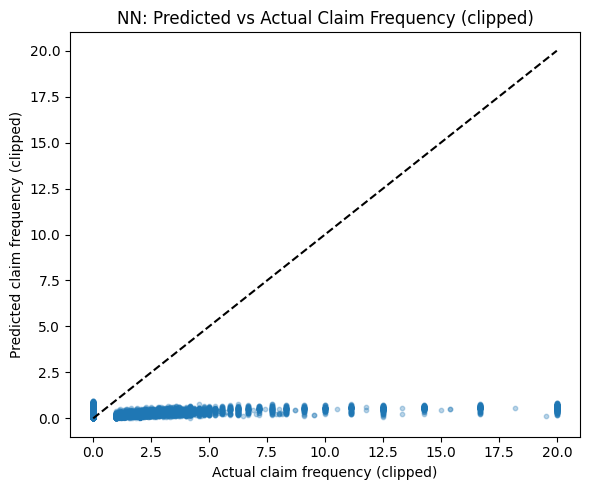

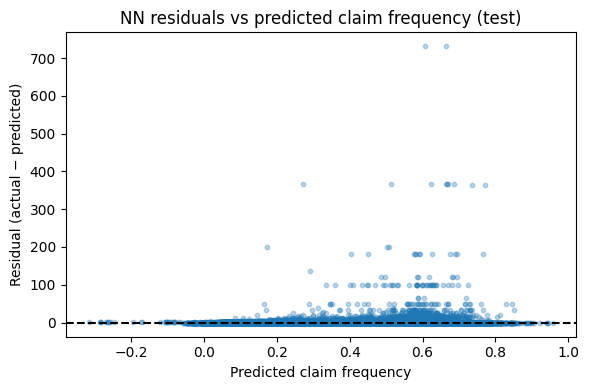

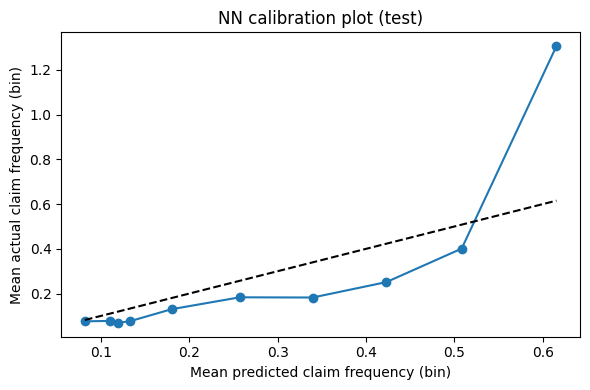

In [29]:
# Visualisation and evaluation for the scratch Feedforward NN
# (assumes the network has already been trained)

import matplotlib.pyplot as plt
import numpy as np

# Predictions
train_preds, _ = forward_prop(features_train, parameters)
test_preds, _  = forward_prop(features_test, parameters)

y_train = labels_train.flatten()
y_test  = labels_test.flatten()

yhat_train = train_preds.flatten()
yhat_test  = test_preds.flatten()

# Predicted vs Actual (TEST)
# Clip extreme frequencies for visualization only
clip_max = 20

y_true_clip = np.clip(labels_test.flatten(), 0, clip_max)
y_pred_clip = np.clip(test_preds.flatten(), 0, clip_max)

plt.figure(figsize=(6, 5))
plt.scatter(y_true_clip, y_pred_clip, s=10, alpha=0.3)
plt.plot([0, clip_max], [0, clip_max], "--", color="black")
plt.xlabel("Actual claim frequency (clipped)")
plt.ylabel("Predicted claim frequency (clipped)")
plt.title("NN: Predicted vs Actual Claim Frequency (clipped)")
plt.tight_layout()
plt.show()

# Residuals vs predicted frequency
residuals = labels_test.flatten() - test_preds.flatten()

plt.figure(figsize=(6, 4))
plt.scatter(test_preds.flatten(), residuals, s=10, alpha=0.3)
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Predicted claim frequency")
plt.ylabel("Residual (actual − predicted)")
plt.title("NN residuals vs predicted claim frequency (test)")
plt.tight_layout()
plt.show()

# Calibration plot
q = 10
bins = np.quantile(test_preds.flatten(), np.linspace(0, 1, q + 1))
bin_id = np.digitize(test_preds.flatten(), bins[1:-1], right=True)

avg_pred, avg_true = [], []

for b in range(q):
    mask = bin_id == b
    if mask.sum() == 0:
        continue
    avg_pred.append(test_preds.flatten()[mask].mean())
    avg_true.append(labels_test.flatten()[mask].mean())

plt.figure(figsize=(6, 4))
plt.plot(avg_pred, avg_true, marker="o")
plt.plot([min(avg_pred), max(avg_pred)],
         [min(avg_pred), max(avg_pred)], "--", color="black")
plt.xlabel("Mean predicted claim frequency (bin)")
plt.ylabel("Mean actual claim frequency (bin)")
plt.title("NN calibration plot (test)")
plt.tight_layout()
plt.show()


In [33]:
# NN from sklearn, used for performance comparison only

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

def load_and_preprocess_for_sklearn():
    data_dir = Path("data")
    train_path = data_dir / "claims_train_clean.csv"
    test_path = data_dir / "claims_test_clean.csv"

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    numeric_cols = ["Exposure", "VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]

    X_train = train_df[numeric_cols].astype(float).values
    X_test = test_df[numeric_cols].astype(float).values

    eps = 1e-8
    y_train = train_df["ClaimNb"].values.astype(float) / (train_df["Exposure"].values.astype(float) + eps)
    y_test = test_df["ClaimNb"].values.astype(float) / (test_df["Exposure"].values.astype(float) + eps)

    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_test_std = scaler.transform(X_test)

    return X_train_std, y_train, X_test_std, y_test

def run_sklearn_mlp():
    X_train, y_train, X_test, y_test = load_and_preprocess_for_sklearn()

    mlp = MLPRegressor(
        hidden_layer_sizes=(6,),
        activation="relu",
        solver="adam",
        learning_rate_init=0.1,
        max_iter=100,
        random_state=0
    )
    
    mlp.fit(X_train, y_train)

    # ---- Compute TRAIN RMSE ----
    y_pred_train = mlp.predict(X_train)
    train_mse = np.sqrt(np.mean((y_pred_train - y_train) ** 2))

    # ---- Compute TEST RMSE ----
    y_pred_test = mlp.predict(X_test)
    test_mse = np.sqrt(np.mean((y_pred_test - y_test) ** 2))

    print(f"Train RMSE: {train_mse:.6f}")
    print(f"Test  RMSE: {test_mse:.6f}")

if __name__ == "__main__":
    run_sklearn_mlp()


Train RMSE: 4.433261
Test  RMSE: 5.209618
